___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Open AI Gym Basics

Let's explore the basics of a **gym** environment, later on we wil interact with it and create agents to learn from it.

In this notebook we will get to know the open ai gym library and its environments:

https://gym.openai.com/

It contains various implementations of tasks on which you can try Reinforcement Learning agents. 

At first we will import the necessary environments

In [1]:
#%pip install gymnasium

In [1]:
import time  # To slown down the game rendering to human speed
import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
dir(gym)

['ActionWrapper',
 'Env',
 'ObservationWrapper',
 'RewardWrapper',
 'Space',
 'VectorizeMode',
 'Wrapper',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'core',
 'envs',
 'error',
 'experimental',
 'logger',
 'make',
 'make_vec',
 'notifications',
 'os',
 'pprint_registry',
 'register',
 'register_envs',
 'registry',
 'spaces',
 'spec',
 'sys',
 'utils',
 'vector',
 'wrappers']

# Python Gymnasium Core Classes
## Core Classes:
- **The Env Class**:
The Env class is the blueprint for all environments. It defines the rules that every environment must follow.<br>
 When you use `gym.make()`, it creates an instance of this class (or a subclass of it).<br>
What it does:
It requires two main functions: <br>
    1. `reset()`: Starts a new episode. <br>
    2. `step(action)`: Takes an action and moves the environment forward.

        #####    Example:
```python
        import gymnasium as gym

        # Create an instance of the Env class using its ID
        env = gym.make("CartPole-v1")

        # Start the environment
        obs, info = env.reset()
        Observation: This is the "current state" of the world. It is what the agent sees.
        In CartPole, it is a list of 4 numbers representing the pole's angle and velocity: [0.01, -0.04, 0.02, 0.01].
        info: A dictionary containing extra details about the reset. At the very beginning of an episode, this is usually empty ({}).


        # Take a random action
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        When the agent takes an action, the environment returns five pieces of information:

        obs (New Observation): The new state of the world after the action was taken. The agent uses this to decide its next move.

        reward (Reward): A number (float or integer) that tells the agent how "good" that specific action was.
                Positive: Good job! (e.g., +1 for keeping the pole up).
                Negative: Bad job! (e.g., -100 for crashing).
                Zero: Neutral.

        terminated (Terminated): A boolean (True or False). It is True if the episode ended because of a natural conclusion or failure.
        Example: The pole fell over, or the agent reached the goal.

        truncated (Truncated): A boolean (True or False). It is True if the episode ended because a time limit was reached.
        Example: The agent survived for 500 steps, but the task isn't technically "finished," so we stop it to save time.
        💡 Tip: To check if an episode is truly over, you usually check both:
            done = terminated or truncated

        info (Info)
        A dictionary with diagnostic data. This is useful for debugging or logging but is not used by the agent to make decisions.
        Example: It might contain the exact physics coordinates or internal game states.
```

- **The Space Class** : The Space class defines what the agent can see (Observations) and what it can do (Actions). It ensures that the data sent between the agent and the environment is in the correct format. <br>
Common Types of Spaces:<br>
        1. `Discrete(n)`:(Discrete) A list of integers from 0 to n-1. (Example: Moving Left=0, Right=1).<br>
        2. `Box(low, high, shape)`: (Continuous) A range of numbers. (Example: A sensor reading between -1.0 and 1.0).

####        Example:
```python
            from gymnasium import spaces

            # Define an action space with 4 possible moves
            action_space = spaces.Discrete(4) # [0 , 1 , 2 , 3]

            # Define an observation space for a 3x3 grid of numbers between 0 and 1
            observation_space = spaces.Box(low=0.0, high=1.0, shape=(3, 3))

            # Check if a value is valid
            print(action_space.contains(2)) # Output: True
            print(action_space.contains(5)) # Output: False
```

- **The Wrapper Class** : Wrappers are essentially a "Data Preprocessing Pipeline" for Reinforcement Learning. A Wrapper is like a filter or a modifier. It sits between your agent and the environment. It allows you to change how the environment behaves without changing the original code. <br> A plugin that changes the game's difficulty or look. Just like Affine Transformations (rotation, scaling, translation) modify an image before it enters a neural network, Wrappers modify the environment's data before it reaches your RL agent.<br>

| Concept | Standard Deep Learning (e.g., Image Classification) | Reinforcement Learning (Gymnasium) |
| :--- | :--- | :--- |
| **Input Data** | Static images from a folder | Live observations from `env.step()` |
| **Preprocessing** | `transforms.Resize()`, `transforms.Normalize()` | `gym.wrappers.ResizeObservation()`, `NormalizeObservation` |
| **Labels/Targets** | Fixed categories in a CSV file | Dynamic rewards from `env.step()` |
| **Scaling Targets** | Not usually applicable | `gym.wrappers.ClipReward()` or `RewardScaling` |
| **Implementation** | Applied via `DataLoader` | Applied via **Wrappers** |

#### Example:
```python
        import gymnasium as gym

        env = gym.make("CartPole-v1")

        # Wrap the environment to record a video of the training
        env = gym.wrappers.RecordVideo(env, video_folder="my_videos")
```


- **ActionWrapper/ObservationWrapper/RewardWrapper**: Specific wrappers to modify different aspects of an environment

    ##### - ActionWrapper:
    This wrapper modifies the action chosen by the agent before it is sent to the environment.<br>
    The Motivation Sometimes, an RL algorithm (like PPO or SAC) prefers to output actions in a standard range like -1.0 to 1.0. <br> 
    However, the environment might require actions in a different range, like 0 to 10. The ActionWrapper bridges this gap.
```python
    import gymnasium as gym

    class ScaleActionWrapper(gym.ActionWrapper):
        def __init__(self, env, scale=10.0):
            super().__init__(env)
            self.scale = scale

        def action(self, action):
            # Agent says "0.5", Environment receives "5.0"
            return action * self.scale

    env = gym.make("Pendulum-v1")
    env = ScaleActionWrapper(env, scale=2.0)
```

##### ObservationWrapper
This wrapper modifies the observation (what the agent sees) before it is returned to the agent.<br>
The Motivation:<br>
Raw data from environments can be messy or too large. We use this wrapper to: <br>
 1. `Simplify`: Turn a color image into grayscale to reduce computation.<br>
 2. `Normalize`: Change pixel values from 0–255 to 0.0–1.0 so the neural network learns faster.<br>
 3. `Resize`: Shrink a 1080p screen down to 84x84 pixels.


 ##### Example:
 ```python
 import gymnasium as gym
import numpy as np

class GrayScaleWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        # Update the observation space to reflect the change
        obs_shape = self.observation_space.shape[:2] # Keep height and width
        self.observation_space = gym.spaces.Box(low=0, high=255, shape=(obs_shape[0], obs_shape[1], 1), dtype=np.uint8)

    def observation(self, obs):
        # Convert RGB to Grayscale by taking the mean of the last axis
        return obs.mean(axis=-1, keepdims=True).astype(np.uint8)

env = gym.make("CarRacing-v3")
env = GrayScaleWrapper(env)
```


##### RewardWrapper: 
This wrapper modifies the reward signal given to the agent after every step. <br>
The Motivation: <br>
Reward signals can sometimes be too "spiky" or large, which makes training unstable. We use this wrapper to: <br>
    1. `Scale`: Multiply rewards by a small number (e.g., 0.01) to keep gradients small. <br>
    2. `Clip`: Limit rewards to a specific range (e.g., -1 to 1). <br>
    3. `Shape`: Add extra "bonus" points for desired behaviors (like staying centered in a lane). <br>

##### Example:
```python
import gymnasium as gym

class ClipRewardWrapper(gym.RewardWrapper):
    def reward(self, reward):
        # Ensure reward is never less than -1 or more than 1
        return max(min(reward, 1.0), -1.0)

env = gym.make("LunarLander-v3")
env = ClipRewardWrapper(env)
```


## Key Functions:
- **make()**: It’s the "Start Game" button. You give it a name (like "LunarLander-v3" or "CartPole-v1"), and it builds that specific simulation for you to play in.

- **register()**: Registers a new environment:  Imagine you invented a brand new game in your backyard, and you want to bring it into the Gymnasium arcade so your AI can play it. <br>
`register()` is how you add your custom game to the official list so `make()` knows it exists. <br>
(As a beginner, you won't need this for a while; you'll just use the games that already exist).

- **make_vec()**:  This stands for "Make Vectorized." Remember how training one puppy takes a long time? What if you could clone your puppy and train 10 of them at the exact same time in 10 identical rooms? That’s what `make_vec()` does. It creates multiple copies of the environment running in parallel so your AI can gather experience much, much faster.

## Important Modules:
**1. spaces**: Contains different space types (Box, Discrete, etc.)

Before you can play a game, you need to know what the $\color{hotpink}{controls}$ look like and what the $\color{cyan}{screen}$ shows you. In RL, we call the 
$\color{hotpink}{\text{controls the Action Space (what the AI can do)}}$ and the $\color{cyan}{\text{screen the Observation Space (what the AI can see)}}$.
The spaces module defines the shape and type of these inputs and outputs. Think of it like choosing the right kind of lock for a door:<br>
`Discrete Space:` This is for simple, distinct choices. Think of a light switch (On/Off) or a classic arcade game like Pac-Man (Up, Down, Left, Right). The AI just picks a single number (like 0, 1, 2, or 3).<br>

`Box Space:` This is for continuous numbers or multiple values at once. Think of a steering wheel in a racing game (you can turn it anywhere between -45 and +45 degrees), or the actual pixels on a screen (a grid of hundreds of numbers representing colors).<br>

Why you care: When you build an AI, you have to look at the environment's spaces so you know whether to build a brain that outputs simple choices (Discrete) or complex steering angles (Box).

**2. envs** : Built-in environments (The Arcade Cabinets)


This is the actual storage warehouse for all the games. Remember `gym.make("LunarLander-v3")` from the last image? The code for Lunar Lander, CartPole, MountainCar, and dozens of other classic training games live inside this envs module.
Why you care: You usually don't need to dig into this folder directly. You just use `gym.make()` (which acts as the front-desk clerk) to fetch the game you want from the envs warehouse. But it's good to know this is where the actual physics and rules for the games are written.

**3. vector**: Parallel environment functionality (The Cloning Machine)

We touched on this briefly with `make_vec()` in the last image. Training an AI by playing one game at a time is incredibly slow. It would be like trying to learn how to ride a bike, but you only get to pedal for 5 seconds a day.
The vector module is the magic cloning machine. It allows you to run 8, 16, or even 128 copies of the exact same game at the exact same time on your computer's processor.
Why you care: Your AI gets to experience 128 lifetimes simultaneously. Instead of learning from one mistake every minute, it learns from 128 mistakes every second. This module is what makes modern AI training actually fast enough to finish before you graduate from college.

**4. wrappers**: Environment modification tools (The Modding Tools)

Remember the ClipRewardWrapper from your first image? That was a wrapper! Sometimes, the built-in games in the envs warehouse aren't quite perfect for the specific AI you are trying to train.
Instead of rewriting the whole complicated game from scratch, you use a Wrapper to "mod" it.
Want to make the screen black-and-white to save memory? There's a wrapper for that.
Want to force the AI to take the same action 4 times in a row? There's a wrapper for that.
Want to squash all the crazy rewards into a simple -1 to +1 scale? Yep, wrapper.
Why you care: Wrappers are your best friend. They let you easily tweak and customize standard games to fit your AI's needs without having to be a master programmer who knows how to write complex physics engines.<br>

<br>

The Grand Summary:<br>
If Gymnasium were a real-life fitness center:
* envs are the actual treadmills and weight machines.
* spaces are the instruction manuals telling you how heavy the weights go and how fast the treadmill can run.
* wrappers are the accessories you add, like putting a towel over the seat or attaching a heart-rate monitor.
* vector is buying a whole row of identical treadmills so your whole family can work out at the exact same time.



The gymnasium library is essential for reinforcement learning as it provides standardized environments and tools to develop and compare RL algorithms. Environments provide a consistent interface with methods like `reset()` to initialize the environment, `step()` to take an action, and `render()` to visualize the state.

Would you like me to elaborate on any specific component or demonstrate how to use gymnasium with a simple example?

Now we can go and chose an environment we want to try and where we want to train an agent on from here:<br />
https://gym.openai.com/envs/

Let's say we want to play the **breakout game** https://gym.openai.com/envs/Breakout-v0/, then we need to perform the following two steps:

1. Define the name of the environment
2. Create the environment

In [10]:
#%pip install gymnasium[atari] ale-py

In [11]:
#%pip install "gymnasium[atari, accept-rom-license]"

In [12]:
import ale_py

In [13]:
# 1. Make the environment:
env_name = "ALE/Breakout-v5"
mode1 = "human"
mode2 = "rgb_array"
env = gym.make(env_name , render_mode = mode2 ) # use gym.make to create your environment

In [14]:
from gymnasium.utils.play import play

In [7]:
play(env , fps = 18 , zoom= 3.5)

Thats all! You successfully created the environment!<br />
Those steps are identical for all environments.

If you want to take a look at your game, gym comes with a handy utils function called **play** for Atari games.<br />
Note that you start the game with *space* and move with *a* and *d*

How many points can you score?

In [31]:
#%pip install pygame

Now after getting to know how we can select an environment and interact with it, it is time to dive deeper into the world of gym.

Gym offers us many functions to interact with the created environment. The most important are:

* reset() - which resets the state of the environment to the initial state. I.e it restarts the game 
* step(action) - performs an action on your environment. In our case it either starts the game or moves to the left, right, or just remains at the current position. It returns the current state of the environment, the reward, if the game is done and some debugging information
* render(mode) - Renders your environment and displays it on your monitor

We will get to know those functions in the next few cells

First we will take a look at the **render** function:<br />
render(mode) takes one argument, namely the render *mode*. *mode* can take two possible values:
* "human"
* "rgb_array"

"human" directly displays the game on your screen, while "rgb_array" returns the array containing the state of the current environment aka the image render shows us.

In [32]:
dir(env)

['__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_action_space',
 '_cached_spec',
 '_disable_render_order_enforcing',
 '_has_reset',
 '_metadata',
 '_np_random',
 '_np_random_seed',
 '_observation_space',
 '_saved_kwargs',
 'action_space',
 'class_name',
 'close',
 'env',
 'get_wrapper_attr',
 'has_reset',
 'has_wrapper_attr',
 'metadata',
 'np_random',
 'np_random_seed',
 'observation_space',
 'render',
 'render_mode',
 'reset',
 'set_wrapper_attr',
 'spec',
 'step',
 'unwrapped',
 'wrapper_spec']

In [8]:
env.render_mode

'rgb_array'

In [15]:
# Reset the environment to start
len(env.reset())

2

In [16]:
env.reset()[0]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(210, 160, 3), dtype=uint8)

In [17]:
env.reset()[1]

{'lives': 5, 'episode_frame_number': 0, 'frame_number': 0}

In [18]:
obs , info = env.reset()

In [19]:
obs.shape

(210, 160, 3)

In [20]:
obs.dtype

dtype('uint8')

In [21]:
%matplotlib inline

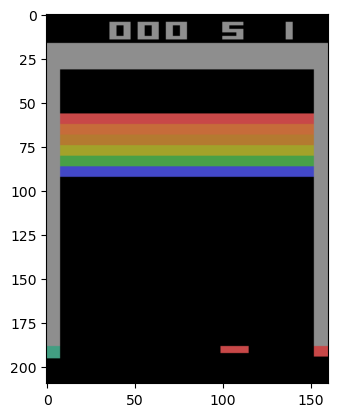

In [22]:
plt.imshow(obs);

In [23]:
env.action_space

Discrete(4)

In [24]:
dir(env.action_space)

['__annotations__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_np_random',
 '_shape',
 'contains',
 'dtype',
 'from_jsonable',
 'is_np_flattenable',
 'n',
 'np_random',
 'sample',
 'seed',
 'shape',
 'start',
 'to_jsonable']

In [25]:
env.action_space.contains

<bound method Discrete.contains of Discrete(4)>

In [26]:
env.action_space.dtype

dtype('int64')

In [27]:
env.action_space.from_jsonable

<bound method Discrete.from_jsonable of Discrete(4)>

In [28]:
env.action_space.is_np_flattenable

True

In [29]:
env.action_space.n

np.int64(4)

In [30]:
env.action_space.np_random

Generator(PCG64) at 0x15879B71380

In [31]:
env.action_space.sample()

np.int64(2)

In [32]:
env.action_space.seed()

289401867334368417379172522489655426460

In [33]:
env.action_space.start

np.int64(0)

In [37]:
obs , info = env.reset()

array = env.render()
print(array.shape)

(210, 160, 3)


In [38]:
env.render().shape

(210, 160, 3)

Note that even we ran 1000 steps over the environment, nothing happened! <br />
This is because no action was taken on this environment.

This is the point where the **step** function joins our game. It performs a selected action on our environment, e.g moving to the left.

You can take a look at the possible actions via the **action_space.n** property.
It returns 4 for our game which is in line with our above findings that we can either start the game, move left or right, or stand still.

In [17]:
print(f"There are {env.action_space.n} possible actions")

There are 4 possible actions


Now it is time to watch some action happening. For this we can select a random possible action.
We could do this by using **numpy.random.randint(0, 4)** or by using the provided sample function **env.action_space.sample()** which directly returns you a possible action.

Note how the "ale.lives" info reduces for each live you lose

In [18]:
env.render_mode

'rgb_array'

In [19]:
import time

If we would now again render the environment, we continue at the same stage we left - thus to start again we need to call the **reset** function.
The reset function returns the initial state of the environment.

In [23]:
env.render()  # Old state of the game

In [24]:
env.close()
state = env.reset()

Now we can again take a look at the game

In [42]:
env = gym.make("ALE/Breakout-v5", render_mode="human")

observation , info = env.reset()

for _ in range(200):
    # display the current state
    env.render()  

    # get the random action    
    random_action = env.action_space.sample() 

    # perform the action the current state of the environment
    observation, reward, terminated, truncated, info = env.step(random_action)
    
    done = terminated or truncated
    
    print(f"Reward: {reward}, Done: {done} , Info: {info}")

    # 5. If the game ends, reset to start a new one
    if done:
        observation , info = env.reset()
    
    time.sleep(0.01)  # slow down the game a bit
    
env.close()  # We shouldn't forget to close the environment

Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 4, 'frame_number': 4}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 8, 'frame_number': 8}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 12, 'frame_number': 12}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 16, 'frame_number': 16}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 20, 'frame_number': 20}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 24, 'frame_number': 24}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 28, 'frame_number': 28}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 32, 'frame_number': 32}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 36, 'frame_number': 36}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 40, 'frame_number': 40}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_num

## Now , let's run the code in way to be visualizable:

%matplotlib inline

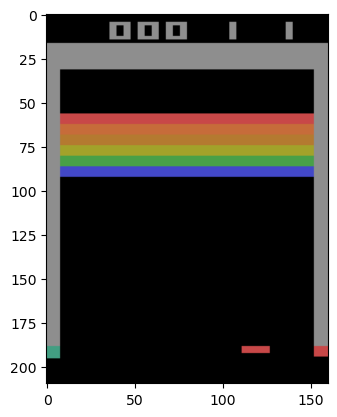

In [44]:
# Reset the environment to start
obs , info = env.reset() # What it does: This is like pressing the "Start Game" button on an arcade machine.
#obs:  (observation): This is the very first screenshot of the game. It's what the robot "sees" right now (the bricks, the ball, the paddle).

for _ in range(200):  # What it does: This tells the computer: "Play the game for exactly 200 frames (or steps), then stop."

    # Take a random action
    action = env.action_space.sample() 
    # What it does: The robot has no idea how to play Breakout. So, it just closes its eyes and picks a random button.
    # In Breakout, the buttons are usually "Move Left", "Move Right", or "Do Nothing". The method sample() just picks one of those at random.
    
    # Step the environment
    observation , reward , terminated , truncated , info = env.step(action)
    # What it does: This actually presses the random button the robot just picked and moves the game forward by one frame.
    # It gives you back 5 things:
    # observation: The new screenshot after the paddle moved.
    # reward: Did you get points? (Usually 0 if you missed, 1 if you hit a brick).
    # terminated: Did you lose all your lives? (Game Over).
    # truncated: Did the game run out of time?
    # info: Extra info again.
    plt.imshow(observation)

    # Render the frame (No arguments needed!)
    env.render() # directly displays you the current state of the game
    # What it does: This takes a snapshot of the screen after the random move was made. 
    # Because you set up %matplotlib inline earlier, this will try to display that snapshot in your notebook.

env.close()

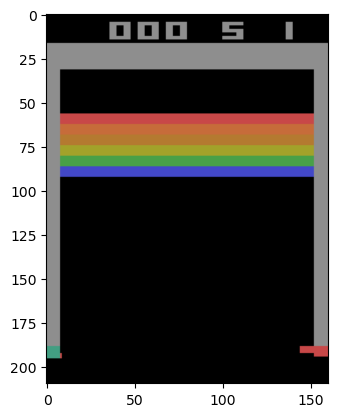

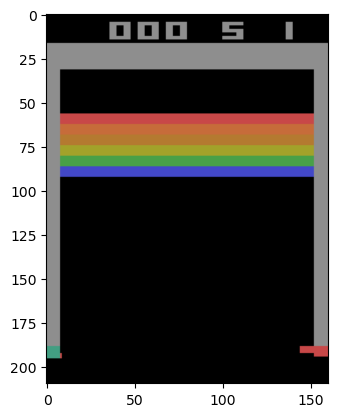

In [43]:
import time
from IPython.display import display , clear_output

# Reset the environment to start
obs , info = env.reset()

for _ in range(20):  # What it does: This tells the computer: "Play the game for exactly 200 frames (or steps), then stop."

    # Take a random action
    action = env.action_space.sample() 
    
    # Step the environment
    observation , reward , terminated , truncated , info = env.step(action)

    clear_output(wait = True)
    plt.imshow(observation)
    display(plt.gcf())
    time.sleep(0.02)

    if terminated or truncated:
        obs , info = env.reset()

env.close()

Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 4, 'frame_number': 4}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 8, 'frame_number': 8}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 12, 'frame_number': 12}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 16, 'frame_number': 16}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 20, 'frame_number': 20}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 24, 'frame_number': 24}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 28, 'frame_number': 28}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 32, 'frame_number': 32}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 36, 'frame_number': 36}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_number': 40, 'frame_number': 40}
Reward: 0.0, Done: False , Info: {'lives': 5, 'episode_frame_num

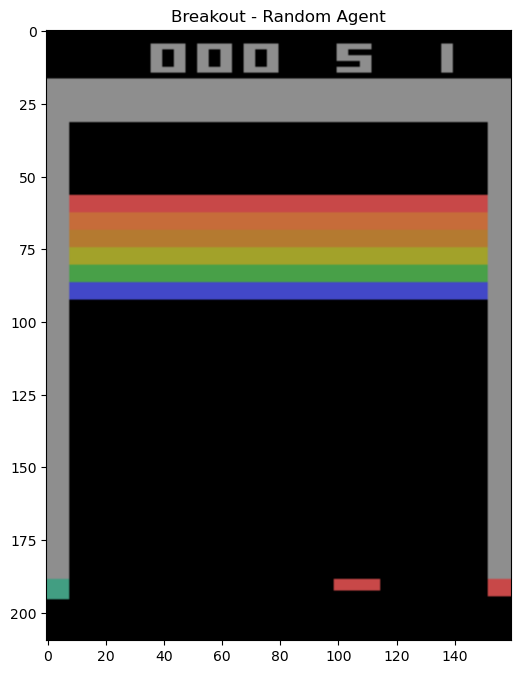

In [29]:
env = gym.make("ALE/Breakout-v5", render_mode="human")

observation , info = env.reset()

plt.figure(figsize=(6,8))
img_plot = plt.imshow(observation)
plt.title("Breakout - Random Agent")

for _ in range(200):
    # display the current state
    env.render()  

    # get the random action    
    random_action = env.action_space.sample() 

    # perform the action the current state of the environment
    observation, reward, terminated, truncated, info = env.step(random_action)
    
    done = terminated or truncated
    
    print(f"Reward: {reward}, Done: {done} , Info: {info}")

    # 5. If the game ends, reset to start a new one
    if done:
        observation , info = env.reset()
    
    time.sleep(0.01)  # slow down the game a bit
    
env.close()  # We shouldn't forget to close the environment

In [12]:
for _ in range(1000):
    env.render(mode="human")  # display the current state
    random_action = env.action_space.sample()  # get the random action
    observation, reward, done, info = env.step(random_action) # perform the action the current state of the environment
    print(f"Reward: {reward}, Done: {done}, Info: {info}")
    if done:  # with the done variable we can leave the loop if gym notifies us that the game is over
        break
    time.sleep(0.01)  # slow down the game a bit
env.close()  # dont forget to close the environment

Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: False, Info: {'ale.lives': 5}
Reward: 0.0, Done: F

Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 3}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: False, Info: {'ale.lives': 2}
Reward: 0.0, Done: F

As you might have noticed, there are always two versions of an environment:

1. RAM Version
2. Normal Version / Image based version

Those version differ in the observation which gym returns to you. <br />
The Ram Version only returns some properties (like the coordinates of the ball), while the normal version returns images (i.e exact the image that render() shows us).



In [13]:
env_name_ram = "Breakout-ram-v0"  # use the RAM version
env_ram = gym.make(env_name_ram)  # create the RAM version of the environment

In [14]:
env_ram.render(mode="human*")

In [15]:
env_ram.close()

In [16]:
env_ram.reset().shape # you can use the reset function to inspect the initial state of your environment.
                      # There are only 128 values instead of the whole image 

(128,)

In [17]:
env.reset().shape  # Our original environment returns an image as observation

(210, 160, 3)

The next notebooks shows an application, where we can directly use the values the RAM version returns to us to create our first little agent that plays a game for us.

Feel free to change the environments in this chapter and try all the available games.
What highscores are you able to achieve?